In [14]:
print("NBA Project Starts Here")

NBA Project Starts Here


In [15]:
import pandas as pd


In [16]:
df = pd.read_csv("games.csv")

In [17]:
#Some of the features we want to use have missing values, so we will drop those rows.
print(df[['FG_PCT_home', 'FT_PCT_home', 'AST_home', 'REB_home', 'PTS_home']].isnull().sum())
print(f'Rows before: {len(df)}')
features = ['FG_PCT_home', 'FT_PCT_home', 'AST_home', 'REB_home', 'PTS_home']
df = df.dropna(subset=features)
print(f'Rows after: {len(df)}')
df.describe()

FG_PCT_home    99
FT_PCT_home    99
AST_home       99
REB_home       99
PTS_home       99
dtype: int64
Rows before: 26651
Rows after: 26552


,GAME_ID,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
count,2.655200e+04,2.655200e+04,2.655200e+04,26552.000000,2.655200e+04,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,2.655200e+04,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000
mean,2.179758e+07,1.610613e+09,1.610613e+09,2012.147861,1.610613e+09,103.455898,0.460735,0.760377,0.356023,22.823441,43.374284,1.610613e+09,100.639876,0.449732,0.758816,0.349489,21.496271,42.113249,0.589221
std,5.536391e+06,8.641202e+00,8.659568e+00,5.569599,8.641202e+00,13.283370,0.056676,0.100677,0.111164,5.193308,6.625769,8.659568e+00,13.435868,0.055551,0.103429,0.109441,5.160596,6.533039,0.491984
min,1.030000e+07,1.610613e+09,1.610613e+09,2003.000000,1.610613e+09,36.000000,0.250000,0.143000,0.000000,6.000000,15.000000,1.610613e+09,33.000000,0.244000,0.143000,0.000000,4.000000,19.000000,0.000000
25%,2.070008e+07,1.610613e+09,1.610613e+09,2007.000000,1.610613e+09,94.000000,0.422000,0.697000,0.286000,19.000000,39.000000,1.610613e+09,91.000000,0.412000,0.692000,0.278000,18.000000,38.000000,0.000000
50%,2.120081e+07,1.610613e+09,1.610613e+09,2012.000000,1.610613e+09,103.000000,0.460000,0.765000,0.357000,23.000000,43.000000,1.610613e+09,100.000000,0.449000,0.765000,0.350000,21.000000,42.000000,1.000000
75%,2.180007e+07,1.610613e+09,1.610613e+09,2017.000000,1.610613e+09,112.000000,0.500000,0.833000,0.429000,26.000000,48.000000,1.610613e+09,110.000000,0.487000,0.833000,0.419000,25.000000,46.000000,1.000000
max,5.210021e+07,1.610613e+09,1.610613e+09,2022.000000,1.610613e+09,168.000000,0.684000,1.000000,1.000000,50.000000,72.000000,1.610613e+09,168.000000,0.687000,1.000000,1.000000,46.000000,81.000000,1.000000


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X = df[['FG_PCT_home', 'FT_PCT_home', 'AST_home', 'REB_home', 'PTS_home']]
y = df['HOME_TEAM_WINS']

#Split the data into training, validation and testing sets
#70% training, 15% validation, 15% testing
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
#Scale the features
scaler =StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

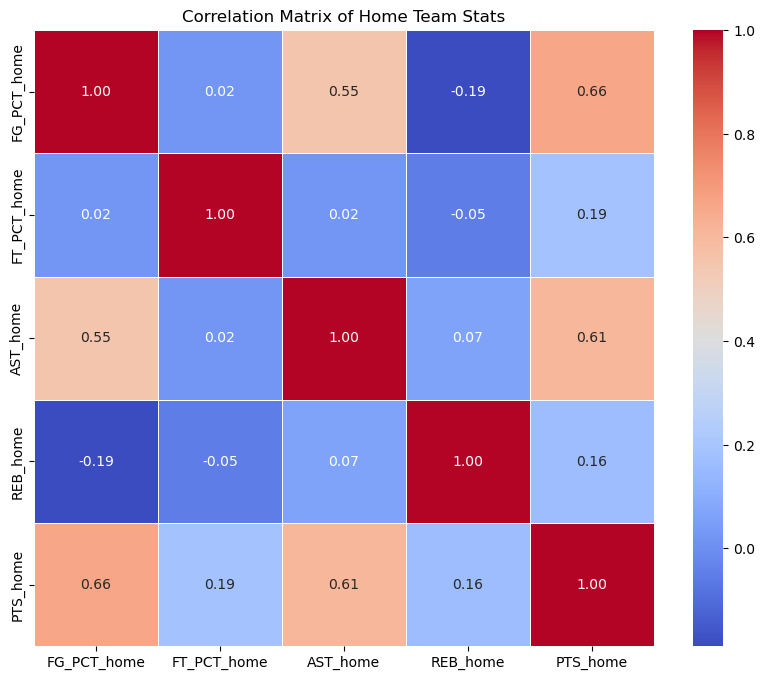

In [19]:
#Visualisation of correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns 

corr_matrix = df[['FG_PCT_home', 'FT_PCT_home', 'AST_home', 'REB_home', 'PTS_home']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of Home Team Stats")
plt.show()

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Function used to evaluate the model and display the confusion matrix
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, name="Model"):
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    print(f"{name} Train Accuracy: {train_acc:.4f}")
    y_val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    print(f"{name} Validation Accuracy: {val_acc:.4f}")
    y_pred= model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} Confusion Matrix")
    plt.show()

Logistic Regression Train Accuracy: 0.7576
Logistic Regression Validation Accuracy: 0.7617
Logistic Regression Accuracy: 0.7622


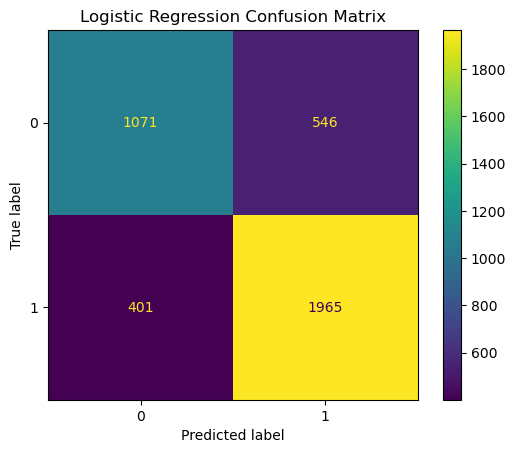

In [34]:
#Logistic Regression Model
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
evaluate_model(log_model, X_train, y_train, X_val, y_val, X_test, y_test, name="Logistic Regression")


In [35]:
#This shows the accuracy of the model.
from sklearn.metrics import accuracy_score
y_pred = log_model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')


Accuracy: 0.762239517951293


In [36]:
#This will show the importance of each feature in the logistic regression model. The higher the score, the more important the feature is in predicting the outcome.
importance = log_model.coef_[0]
for i, v in enumerate(importance):
    print(f'Feature: {X.columns[i]}, Score: {v:.5f}')

Feature: FG_PCT_home, Score: 1.52137
Feature: FT_PCT_home, Score: 0.32086
Feature: AST_home, Score: 0.04644
Feature: REB_home, Score: 1.02738
Feature: PTS_home, Score: -0.08533


Random Forest Train Accuracy: 0.9999
Random Forest Validation Accuracy: 0.7484
Random Forest Accuracy: 0.7376


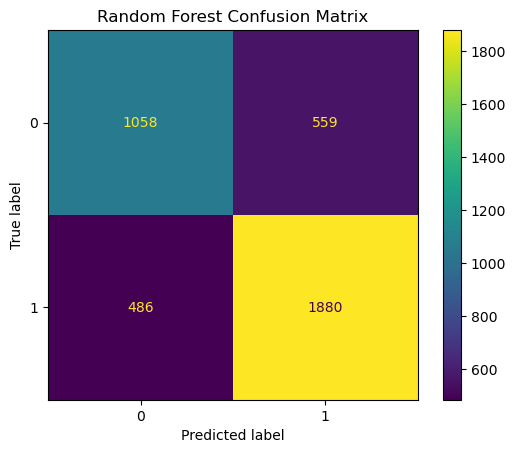

In [37]:
#Random Forest Model
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

evaluate_model(rf_model, X_train, y_train, X_val, y_val, X_test, y_test, name="Random Forest")

In [29]:
#
from sklearn.metrics import classification_report, confusion_matrix
predictions = log_model.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.73      0.66      0.69      1617
           1       0.78      0.83      0.81      2366

    accuracy                           0.76      3983
   macro avg       0.76      0.75      0.75      3983
weighted avg       0.76      0.76      0.76      3983



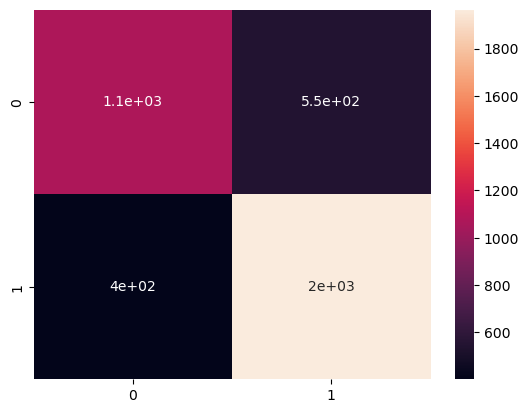

In [30]:
#Visualisaton of confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True)
plt.show()

In [31]:
#Correlation Matrix
cols_to_correlate = ['FG_PCT_home', 'FT_PCT_home', 'AST_home', 'REB_home', 'PTS_home', 'HOME_TEAM_WINS']
corr_matrix = df[cols_to_correlate].corr()
print(corr_matrix)

                FG_PCT_home  FT_PCT_home  AST_home  REB_home  PTS_home  \
FG_PCT_home        1.000000     0.021179  0.550769 -0.188416  0.662165   
FT_PCT_home        0.021179     1.000000  0.022611 -0.051505  0.187056   
AST_home           0.550769     0.022611  1.000000  0.066184  0.605409   
REB_home          -0.188416    -0.051505  0.066184  1.000000  0.162274   
PTS_home           0.662165     0.187056  0.605409  0.162274  1.000000   
HOME_TEAM_WINS     0.432700     0.093394  0.301750  0.245884  0.395810   

                HOME_TEAM_WINS  
FG_PCT_home           0.432700  
FT_PCT_home           0.093394  
AST_home              0.301750  
REB_home              0.245884  
PTS_home              0.395810  
HOME_TEAM_WINS        1.000000  
